In [2]:
import sys
sys.path.append('../')
from utils_models import *

In [10]:
Er = 2.97
g =  0.2 
kappa = 4e-2 # kappa = Er * 2pi/Q =0.1

max_ql = 5
max_ol = 2
system = FluxoniumOscillatorSystem(
    EJ = 2.65,
    EC = 0.6,
    EL = 0.13,
    Er = Er,
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    kappa = kappa, 
    products_to_keep=[[ql, ol] for ql in range(8) for ol in range(4) ],
    computaional_states = '0,1',
    )


evals, evecs = system.hilbertspace.hamiltonian().eigenstates()
overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)
def print_top_two_dressed_state(product_index):
    overlaps_with_product_state = np.abs(overlap_matrix[:, product_index])
    sorted_indices = np.argsort(overlaps_with_product_state)[::-1]
    sorted_overlaps = overlaps_with_product_state[sorted_indices]
    print(list(sorted_indices)[:2])
    print(list(sorted_overlaps)[:2])
print_top_two_dressed_state(0 * system.osc.truncated_dim + 1) # Find what dressed states make up the g1 (01) product state
print_top_two_dressed_state(3 * system.osc.truncated_dim + 0) # Find what dressed states make up the h0 (30) product state
print_top_two_dressed_state(4 * system.osc.truncated_dim + 0) # Find what dressed states make up the (40) product state


[4, 3]
[0.7294625359303359, 0.6825567863878365]
[3, 4]
[0.7297040699608195, 0.6830980259904577]
[5, 8]
[0.9924936126655626, 0.0921716949131444]


# want to know how easy it is to exchange a photon for 0->3 transition

In [32]:
tlist = np.linspace(0,1000,1000)
results = system.run_mesolve_parrallel(
    initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, 4))],
    tlist = tlist,
    c_ops=system.c_ops,
    drive_terms=[],
    e_ops=[
        system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension,i))) for i in [0,1,2,3,4,5,6,7]
    ],
)

 Total run time:   4.42s*] Elapsed 4.42s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 1000/1000 [00:00<00:00, 9479.12it/s]


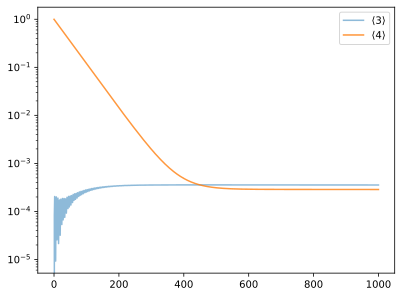

In [35]:
plt.plot(tlist,results[0].expect[3],label=fr'$\langle{3}\rangle$',alpha = 0.5)
plt.plot(tlist,results[0].expect[4],label=fr'$\langle{4}\rangle$',alpha = 0.8)
plt.legend()
plt.yscale('log')


# drive qubit, purcell decay

In [11]:

qbt_operator_element = np.abs(system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.qbt.n_operator))[2,3]) 
print(qbt_operator_element)
oscillator_operator_element = np.abs(system.truncate_function(
    system.hilbertspace.op_in_dressed_eigenbasis(system.osc.annihilation_operator)
    + system.hilbertspace.op_in_dressed_eigenbasis(system.osc.creation_operator)
    )[2,3]) 
print(oscillator_operator_element)


qbt_operator_element24 = np.abs(system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.qbt.n_operator))[2,4]) 
print(qbt_operator_element24)
oscillator_operator_element24 = np.abs(system.truncate_function(
    system.hilbertspace.op_in_dressed_eigenbasis(system.osc.annihilation_operator)
    + system.hilbertspace.op_in_dressed_eigenbasis(system.osc.creation_operator)
    )[2,4]) 
print(oscillator_operator_element24)


Gamma = kappa*g**2/(evals[3]-evals[0] - Er)**2
print(f"purcell decay rate {Gamma}")


amp = 0.03
square_t_stop = 0.5 / qbt_operator_element /amp
print(f"square_t_stop:{square_t_stop}")
t_rise = 30
area_under_square  = square_t_stop
area_under_rise_and_fall = t_rise
t_stop = 2 * t_rise + (area_under_square-area_under_rise_and_fall)
tot_time = int(t_stop + 500)
tlist = np.linspace(0, tot_time, tot_time)
kappa = 3e-2


0.12360757458023894
0.0160983998741849
0.11022314205255783
0.016743340549993102
purcell decay rate 0.1337794479339526
square_t_stop:134.83531833114017


In [12]:
results = system.run_mesolve_parrallel(
    initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) for i in range(3)],
    tlist = tlist,
    drive_terms = [
        DriveTerm(
            driven_op =system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.qbt.n_operator)),
            pulse_shape_func = square_pulse_with_rise_fall,
            pulse_shape_args={
                'w_d': system.hilbertspace.energy_by_bare_index((2,1))-system.hilbertspace.energy_by_bare_index((2,0)),
                'amp':amp,
                't_rise':t_rise,
                't_square': t_stop-2*t_rise,
            }
        )
    ],
    c_ops=system.c_ops,
    e_ops=[# we want to get the expectation value of the system being in every one of its eigenstates
        system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension,i))) for i in [0,1,2,3,4,5,6,7]
    ],
)


 Total run time:   2.82s*] Elapsed 2.82s / Remaining 00:00:00:000[*********70%****       ] Elapsed 2.07s / Remaining 00:00:00:00
 [*********65%***        ] Elapsed 2.83s / Remaining 00:00:00:01

Processing states with pad_back_custom: 100%|██████████| 664/664 [00:00<00:00, 9307.81it/s]


 Total run time:   2.89s*] Elapsed 2.89s / Remaining 00:00:00:00
 Total run time:   3.75s*] Elapsed 3.75s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 664/664 [00:00<00:00, 9365.31it/s]


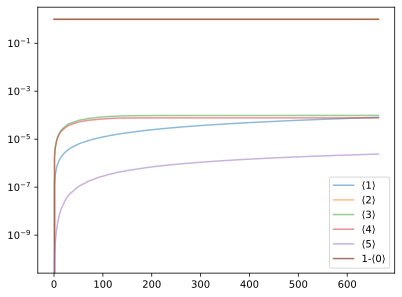

In [13]:
## For system starting in dressed state 2 
# (which is f0, the leakage state we are addressing) 
# about 99.99% of the population has gone to state 0 (which is g0) at 700 ns
for i in [1,2,3, 4,5]:
    plt.plot(tlist,results[2].expect[i],label=fr'$\langle{i}\rangle$',alpha = 0.5)
plt.plot(tlist,1-results[2].expect[0],label=fr'1-$\langle{0}\rangle$',alpha = 0.8)
plt.legend()
plt.yscale('log')


# drive oscillator, oscillator decay

In [25]:
amp = 0.03
square_t_stop = 0.5 / qbt_operator_element24 /amp +86
print(f"square_t_stop:{square_t_stop}")
# t_rise = 30
# area_under_square  = square_t_stop
# area_under_rise_and_fall = t_rise
# t_stop = 2 * t_rise + (area_under_square-area_under_rise_and_fall)
tot_time = int(square_t_stop + 500)
tlist = np.linspace(0, tot_time, tot_time)


square_t_stop:237.20841554960828


In [26]:
results = system.run_mesolve_parrallel(
    initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) for i in range(3)],
    tlist = tlist,
    drive_terms = [
        DriveTerm(
            # driven_op =system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.qbt.n_operator)),
            driven_op =system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.qbt.n_operator)),
            pulse_shape_func = square_pulse_with_rise_fall,
            pulse_shape_args={
                'w_d': system.hilbertspace.energy_by_bare_index((0,1))-system.hilbertspace.energy_by_bare_index((2,0)),
                'amp':amp,
                # 't_rise':t_rise,
                't_square': square_t_stop,
            }
        )
    ],
    c_ops=system.c_ops,
    e_ops=[# we want to get the expectation value of the system being in every one of its eigenstates
        system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension,i))) for i in [0,1,2,3,4,5,6,7]
    ],
)


 Total run time:   3.19s*] Elapsed 3.19s / Remaining 00:00:00:00 [*********89%********   ] Elapsed 3.07s / Remaining 00:00:00:00
 [*********91%*********  ] Elapsed 3.24s / Remaining 00:00:00:00

Processing states with pad_back_custom: 100%|██████████| 737/737 [00:00<00:00, 8978.69it/s]


 Total run time:   3.45s*] Elapsed 3.45s / Remaining 00:00:00:00
 Total run time:   3.53s*] Elapsed 3.53s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 737/737 [00:00<00:00, 9254.49it/s]


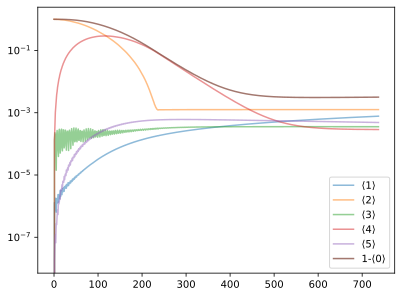

In [27]:
## For system starting in dressed state 2 
# (which is f0, the leakage state we are addressing) 
# about 99.99% of the population has gone to state 0 (which is g0) at 700 ns
for i in [1,2,3, 4,5]:
    plt.plot(tlist,results[2].expect[i],label=fr'$\langle{i}\rangle$',alpha = 0.5)
plt.plot(tlist,1-results[2].expect[0],label=fr'1-$\langle{0}\rangle$',alpha = 0.8)
plt.legend()
plt.yscale('log')


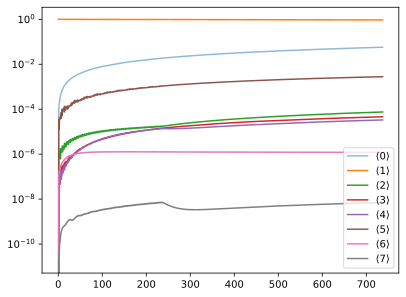

In [28]:
## For system starting in dressed state 1 (which is e0, a computational state) the worried qubit 1-4 transition only happens at a level of 1e-4

plt.plot(tlist,results[1].expect[0],label=fr'$\langle{0}\rangle$',alpha = 0.5)

for i in [1,2,3,4,5,6,7]:
    plt.plot(tlist,results[1].expect[i],label=fr'$\langle{i}\rangle$')
plt.legend()
# plt.ylim(0,1e-3)

plt.yscale('log')
# plt.xlim(0,186)

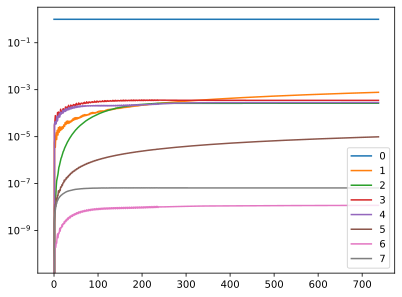

In [29]:
## For system starting in dressed state 0 (which is g0, a computational state) there's also some leakage on the level of 1e-5

for i in [0,1,2,3,4,5,6,7]:
    plt.plot(tlist,results[0].expect[i],label=f'{i}')
plt.legend()

plt.yscale('log')
